In [2]:
import numpy as np
import matplotlib.pyplot as plt

In [3]:
nx = 20   # number of space intervals
nt = 100  # number of time steps
T = 0.1   # total time

x = np.linspace(0,1,nx+1)
dx = 1/nx     # space intervals length
dt = T/nt     # time intervals length
r = dt/dx**2  # mesh ratio
print("r = ",r)

r =  0.3999999999999999


In [4]:
u = np.sin(np.pi * x)
u[0] = 0   # boundary conditions
u[-1] = 0

In [5]:
for n in range(nt):   # ftcs loop
    u_new = u.copy()
    for i in range(1,nx):
        u_new[i] = u[i] + r * (u[i+1] - 2*u[i] + u[i-1])
    u = u_new

In [6]:
u_exact = np.exp(-np.pi**2 * T) * np.sin(np.pi * x)   # exact solution

max error =  0.001062511783011033


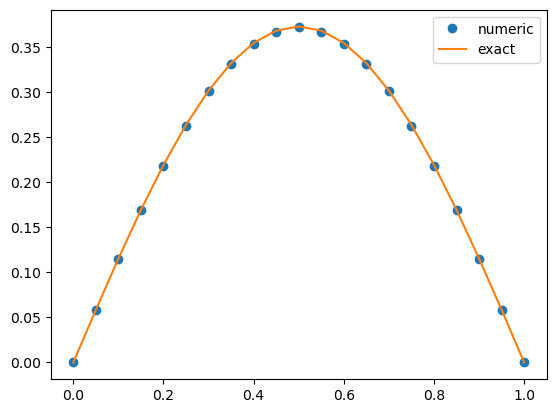

In [8]:
print("max error = ", np.max(np.abs(u - u_exact)))

# max error and graph

plt.plot(x, u, "o", label = "numeric")
plt.plot(x, u_exact, "-", label = "exact")
plt.legend(); plt.show()

Wrapping the method in a function to run experiments

In [10]:
def ftcs(nx, nt, T=0.1):
    x = np.linspace(0, 1, nx + 1)
    dx = 1 / nx
    dt = T / nt
    r = dt / dx**2
    u = np.sin(np.pi * x)
    u[0] = u[-1] = 0
    for n in range(nt):
        u_new = u.copy()
        for i in range(1, nx):
            u_new[i] = u[i] + r * (u[i+1] - 2*u[i] + u[i-1])
        u = u_new
    return x, u, r

In [18]:
def exact(x, T=0.1):
    return np.exp(-np.pi**2 * T) * np. sin(np.pi * x)

Experimenting with 20 space intervals and 100 time steps

error =  0.001062511783011033


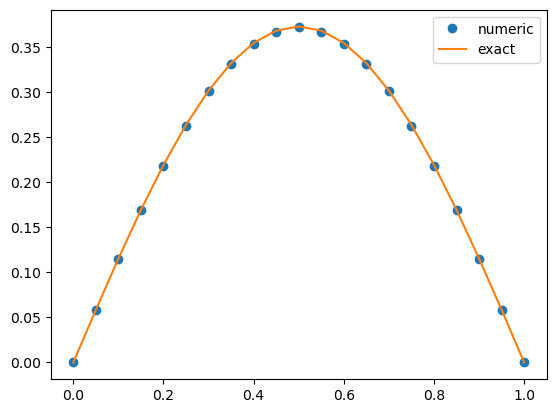

In [19]:
x, u, r = ftcs(nx=20, nt=100)

print("error = ", np.max(np.abs(u - exact(x))))

plt.plot(x, u, "o", label = "numeric")
plt.plot(x, u_exact, "-", label = "exact")
plt.legend(); plt.show()

Experimenting with 20 space intervals and 50 time steps

error =  1.1560365468412717


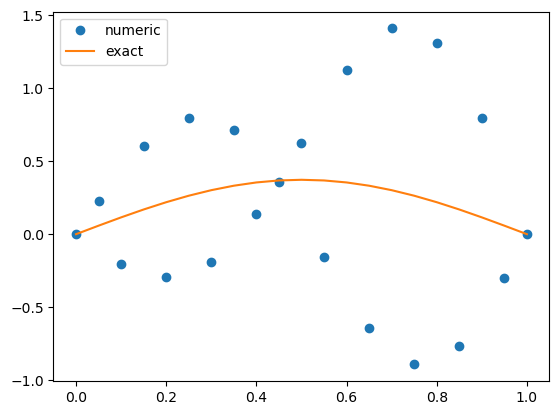

In [20]:
x, u, r = ftcs(nx=20, nt=50)

print("error = ", np.max(np.abs(u - exact(x))))

plt.plot(x, u, "o", label = "numeric")
plt.plot(x, u_exact, "-", label = "exact")
plt.legend(); plt.show()

Sweeping r with 40 space intervals

In [21]:
nx = 40
for nt in [400, 320, 300, 280, 250, 200]:
    x, u, r = ftcs(nx, nt)
    err = np.max(np.abs(u - exact(x)))
    print(f"nt = {nt:4d}   r = {r:3f}   error = {err:.3e}")

nt =  400   r = 0.400000   error = 2.649e-04
nt =  320   r = 0.500000   error = 3.786e-04
nt =  300   r = 0.533333   error = 1.806e-01
nt =  280   r = 0.571429   error = 5.889e+12
nt =  250   r = 0.640000   error = 1.664e+31
nt =  200   r = 0.800000   error = 1.944e+51


For nx = 40, the error stays around 1e-4 while r <= 0.5. Just above that
threshold (r = 0.533) it jumps to ~0.2, and for r >= 0.571 it blows up
(1e13 and beyond). Since r = dt/dx^2, keeping r <= 1/2 requires nt to grow
like nx^2: the explicit scheme is only conditionally stable.